In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(palette="deep")

# Wczytanie danych

In [51]:
data = pd.read_csv(r"data.csv", dtype = {"link_flair_text": "string"})

data["date"] = pd.to_datetime(data["created_date"])
data["year"]  = data["date"].dt.year

data["figure"] = data["postac"]

data = data[[
    "figure",
    "type",
    "subreddit",
    # "subreddit_id",
    # "created_utc",
    "date",
    "year",
    "id",
    "parent_id",
    # "link_id",
    "author",
    "title",
    "body",
    # "ups",
    # "downs",
    "score",
    "over_18"
]]

data.head(2)

,figure,type,subreddit,date,year,id,parent_id,author,title,body,score,over_18
0,MileyCyrus,comments,cyrus,2017-06-13,2017,dittstm,t3_6gvhln,cysenberg,NaN,I can't believe this sub is devoted to that ho...,1,NaN
1,MileyCyrus,comments,cyrus,2017-06-13,2017,ditveid,t1_dittstm,cy_guy,NaN,?? what did ido???,1,NaN


In [3]:
# data[data["author"].str.contains("bot")].author.unique()

# Wyczyszczenie zbioru danych

In [47]:
removed_text = {"[deleted]", "[removed]", "deleted", "removed", ""}
known_bots = {
    "AutoModerator", "autotldr", 
    "tweettranscriberbot", "transcribersofreddit",
    "RemindMeBot", "twitterInfo_bot", 
    "hannahmontana-ModTeam", "mileycyrus-ModTeam", "miley-ModTeam", "QueenMileyCyrus-ModTeam",
    'killbot2_0',
    'bruh__bot',
    'bot-the-builder',
    'phonebatterylevelbot',
    'smile-bot-2019',
    'patrick_bot3',
    'june-bot',
    'exclaim_bot',
    'yahoo_bot',
    'a_compliment_bot',
    'autourbanbot',
    'instagrambot',
    'DealWithItbot',
    'totes_meta_bot',
    'gifv-bot',
    'youtubefactsbot',
    'sneakpeekbot',
    'imguralbumbot',
    'anti-gif-bot',
    'I_am_a_haiku_bot',
    'tweettranscriberbot',
    'serendipitybot',
    'lerobinbot',
    'the_timezone_bot',
    'reversenwordbot',
    'redditspeedbot',
    'timee_bot',
    'haikusbot',
    'twitterInfo_bot',
    'wikipedia_answer_bot',
    'songacronymbot',
    'of_patrol_bot',
    'alphabet_order_bot',
    'metric_robot',
    'outline_link_bot',
    'SpambotSwattr',
    'Cinnabot2026'
}

removed_body_mask = (data["type"] == "comments") & data["body"].fillna("").astype(str).str.strip().str.lower().isin(removed_text)
removed_title_mask = (data["type"] == "posts") & data["title"].fillna("").astype(str).str.strip().str.lower().isin(removed_text)

cleaned_author = data["author"].fillna("").astype(str).str.strip()
bot_mask = cleaned_author.isin(known_bots) | cleaned_author.str.lower().isin(removed_text)

pd.DataFrame({
    " ": [
        "no before cleaning",
        "no removed comments",
        "no removed posts (titles)",
        "no bots",
        "no after cleaning"
    ],
    "count": [
        len(data),
        int(removed_body_mask.sum()),
        int(removed_title_mask.sum()),
        int(bot_mask.sum()),
        int((~removed_body_mask & ~removed_title_mask & ~bot_mask).sum())
    ]
})

,,count
0,no before cleaning,108840
1,no removed comments,6271
2,no removed posts (titles),0
3,no bots,15387
4,no after cleaning,93451


In [48]:
data = data.loc[~removed_body_mask & ~removed_title_mask & ~bot_mask].copy()

# Sprawdzenie braków danych

In [49]:
data.isnull().sum() # zgadza się wszystko, braki w oznaczeniu treści 18+

type             0
subreddit        0
date             0
year             0
id               0
parent_id    19856
author           0
title        73595
body         19856
score            0
over_18      73595
dtype: int64

# EDA

## 1. Zliczenie wierszy dla subredditów i typu (post, komentarz)

In [55]:
subreddit_type_count = data.pivot_table(
    index=["figure", "type"],
    columns="subreddit",
    values="id",
    aggfunc="count",
    fill_value=0
)
subreddit_type_count["TOTAL"] = subreddit_type_count.sum(axis=1)
subreddit_type_count = subreddit_type_count.sort_values(by="TOTAL", ascending=False)
subreddit_type_count.loc["TOTAL"] = subreddit_type_count.sum(numeric_only=True)

subreddit_type_count

subreddit,cyrus,hannahmontana,miley,mileycyrus,queenmileycyrus,TOTAL
"(MileyCyrus, comments)",4892,0,5357,38058,20942,69249
"(MileyCyrus, posts)",2464,0,2136,13974,3593,22167
"(HannahMontana, comments)",0,15400,0,101,0,15501
"(HannahMontana, posts)",0,1700,0,223,0,1923
TOTAL,7356,17100,7493,52356,24535,108840


In [58]:
17100/(15501+1923)

0.981404958677686

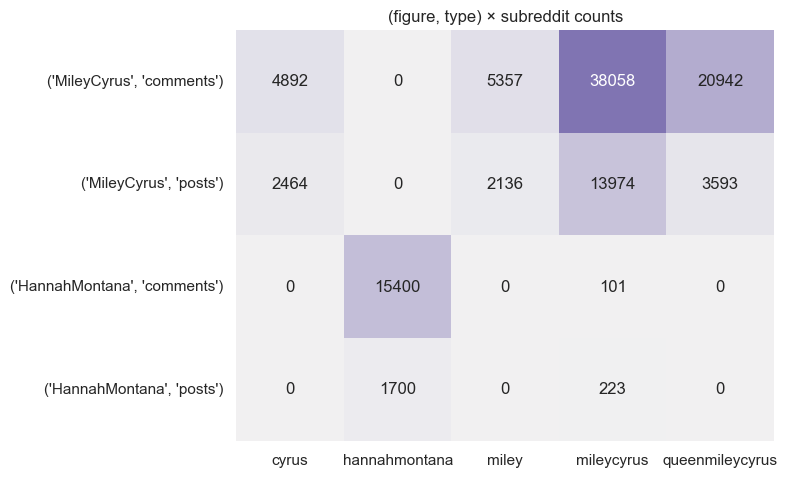

In [57]:
plt.figure(figsize=(8, 8/1.618))
sns.heatmap(
    subreddit_type_count.drop(index="TOTAL", columns="TOTAL"),
    annot=True,        # wartości w komórkach
    fmt="g",           # bez formatowania float
    cmap=sns.light_palette("#8074B2", as_cmap=True),
    cbar=False
)

plt.title("(figure, type) × subreddit counts")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 2. Liczba wpisów (posty i komentarze) na każdym z subredditów

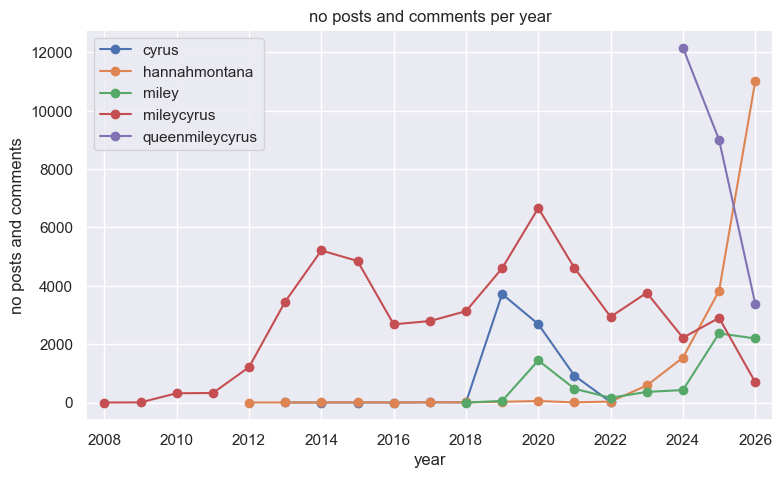

In [59]:
subreddit_time_count = (
    data.groupby(["subreddit", "year"])
    .size()
    .reset_index(name="count")
)

fig, ax = plt.subplots(figsize=(8, 8/1.618))

for sub, group in subreddit_time_count.groupby("subreddit"):
    group = group.sort_values("year")
    ax.plot(group["year"], group["count"], marker="o", label=sub)

ax.set_title("no posts and comments per year")
ax.set_xlabel("year")
ax.set_ylabel("no posts and comments")

ax.set_xlim(2007.5, 2026.5)
ax.set_xticks(np.arange(2008, 2027, 2))

ax.legend()
plt.tight_layout()
plt.show()

In [29]:
subreddit_time_range = data.groupby("subreddit")["date"].agg(
    min_date="min",
    max_date="max"
).sort_values(by="min_date")
subreddit_time_range

,min_date,max_date
subreddit,,
mileycyrus,2008-10-30,2026-05-13
hannahmontana,2013-04-04,2026-05-14
cyrus,2013-11-28,2022-01-22
miley,2018-07-05,2026-05-14
queenmileycyrus,2024-01-14,2026-05-14


## 3. Rozkład długości komentarzy i postów

Index(['cyrus', 'mileycyrus', 'queenmileycyrus', 'miley', 'hannahmontana'], dtype='object', name='subreddit')


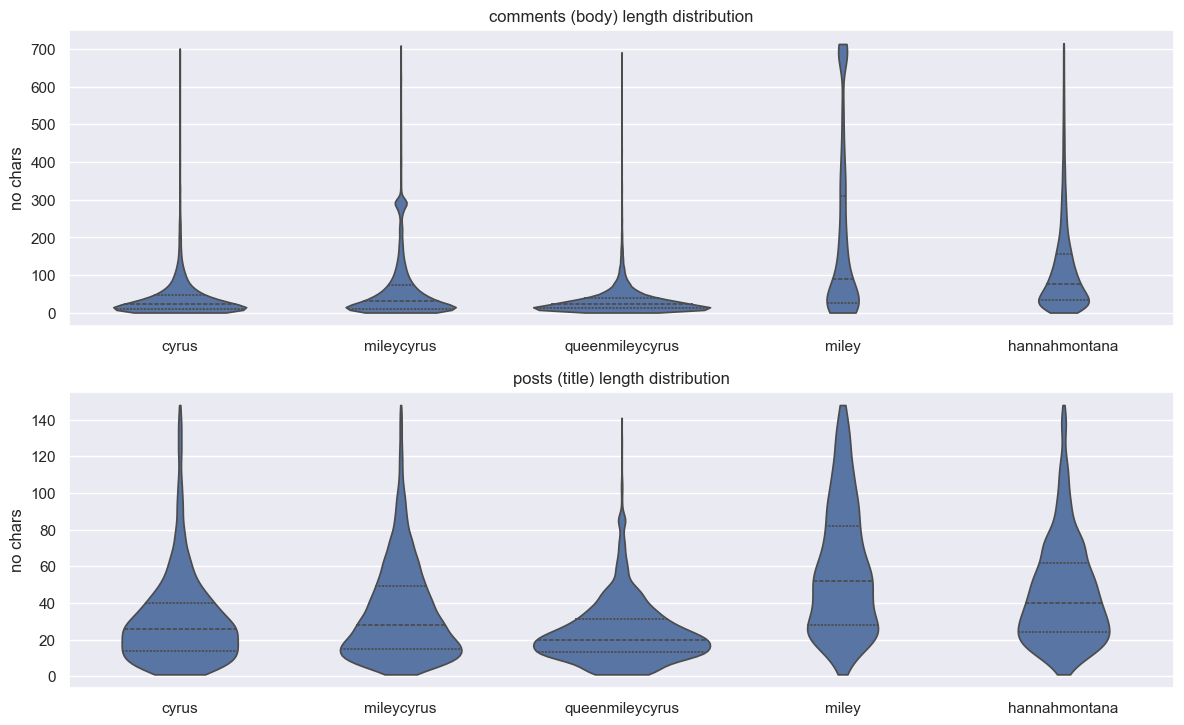

In [61]:
data["lo_body"] = data["body"].fillna("").str.len()
data["lo_title"] = data["title"].fillna("").str.len()

order = (
    data.groupby("subreddit")["lo_body"]
    .median()
    .sort_values()
    .index
)
print(order)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12/1.618))

data_body = data[
    (data["type"] == "comments") &
    (data["lo_body"] <= data["lo_body"].quantile(0.995))
]
sns.violinplot(
    data=data_body,
    x="subreddit",
    y="lo_body",
    order=order,
    cut=0,
    inner="quartile",
    ax=ax1
)

ax1.set_title("comments (body) length distribution")
ax1.set_xlabel("")
ax1.set_ylabel("no chars")
ax1.tick_params(axis="x", rotation=0)


data_title = data[
    (data["type"] == "posts") &
    (data["lo_title"] <= data["lo_title"].quantile(0.995))
]
sns.violinplot(
    data=data_title,
    x="subreddit",
    y="lo_title",
    order=order,
    cut=0,
    inner="quartile",
    ax=ax2
)

ax2.set_title("posts (title) length distribution")
ax2.set_xlabel("")
ax2.set_ylabel("no chars")
ax2.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 4. Liczba unikalnych autorów

In [31]:
subreddit_unique_author_count = data.pivot_table(
    index="subreddit",
    columns="type",
    values="author",
    aggfunc="nunique",
    fill_value=0
)
subreddit_unique_author_count["TOTAL"] = subreddit_unique_author_count.sum(axis=1)
subreddit_unique_author_count = subreddit_unique_author_count.sort_values(by="TOTAL", ascending=False)
subreddit_unique_author_count.loc["TOTAL"] = subreddit_unique_author_count.sum(numeric_only=True)

subreddit_unique_author_count

type,comments,posts,TOTAL
subreddit,,,
mileycyrus,8621,5319,13940
hannahmontana,4334,902,5236
cyrus,1726,1106,2832
queenmileycyrus,1944,545,2489
miley,1702,459,2161
TOTAL,18327,8331,26658


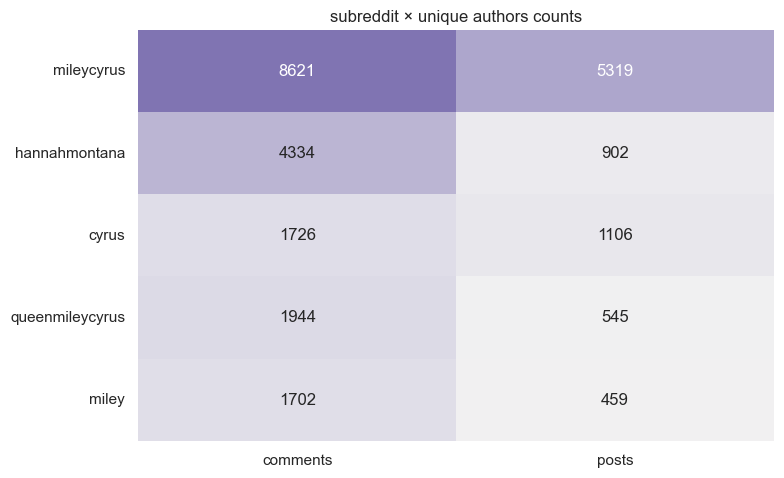

In [32]:
plt.figure(figsize=(8, 8/1.618))
sns.heatmap(
    subreddit_unique_author_count.drop(index="TOTAL", columns="TOTAL"),
    annot=True,        # wartości w komórkach
    fmt="g",           # bez formatowania float
    cmap=sns.light_palette("#8074B2", as_cmap=True),
    cbar=False
)

plt.title("subreddit × unique authors counts")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

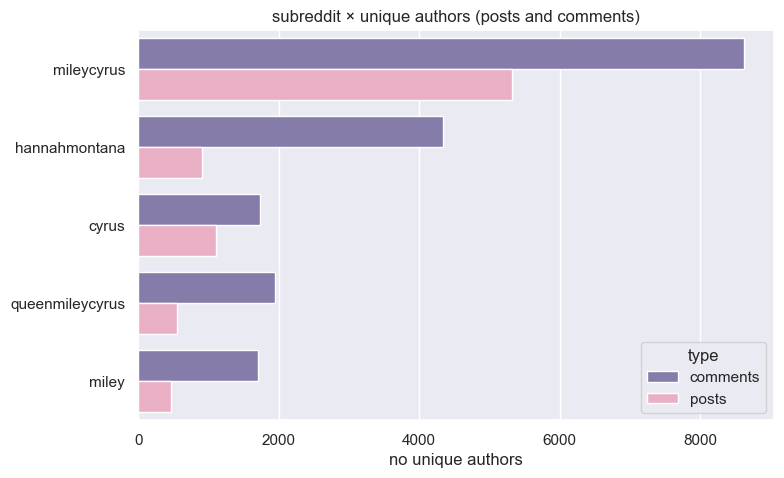

In [33]:
unique_authors_count = (
    subreddit_unique_author_count
    .drop(index="TOTAL", columns="TOTAL")
    .reset_index()
    .melt(id_vars="subreddit", var_name="type", value_name="count")
)

plt.figure(figsize=(8, 8/1.618))

sns.barplot(
    data=unique_authors_count,
    x="count",
    y="subreddit",
    hue="type",
    palette=["#8074B2", "#F2A7C3"]
)

plt.title("subreddit × unique authors (posts and comments)")
plt.xlabel("no unique authors")
plt.ylabel("")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 5. Najaktywniejsi użytkownicy (autorzy)

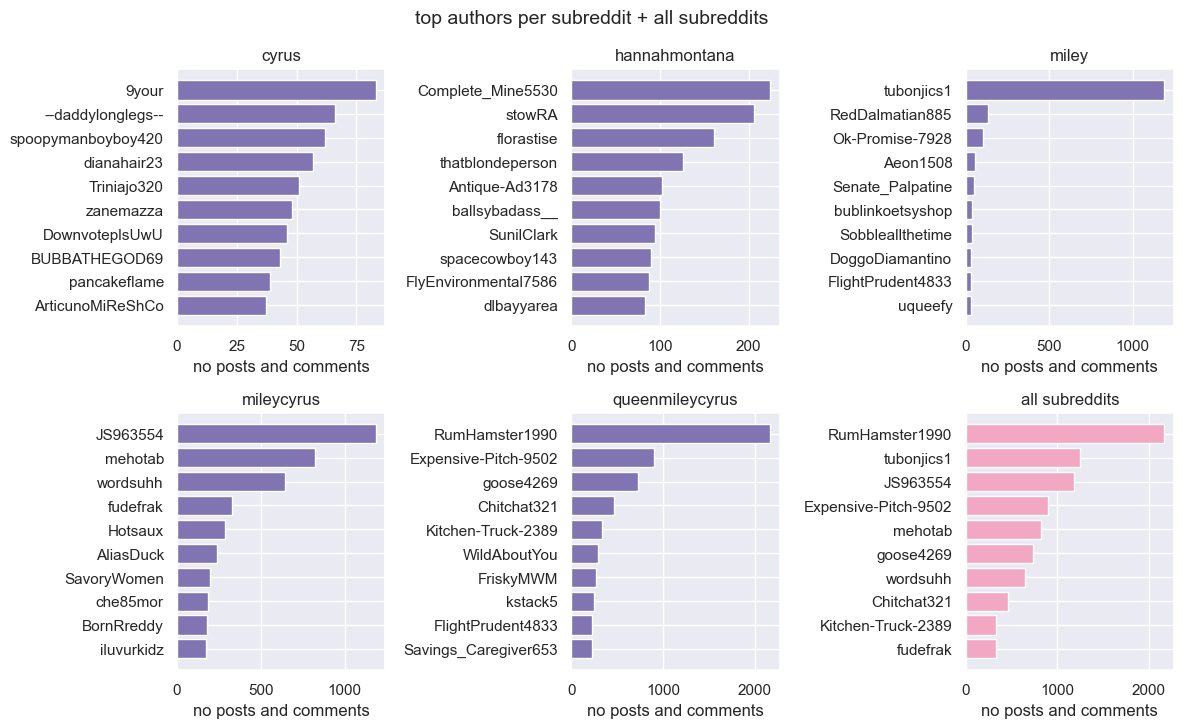

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(12, 12/1.618))
fig.suptitle("top authors per subreddit + all subreddits", fontsize=14)

axes = axes.flatten()
for i, (sub, group) in enumerate(data.groupby("subreddit")):
    top = group["author"].value_counts().head(10)
    axes[i].barh(top.index[::-1], top.values[::-1], color="#8074B2")
    axes[i].set_title(f"{sub}")
    axes[i].set_xlabel("no posts and comments")

global_top = data["author"].value_counts().head(10)
axes[5].barh(
    global_top.index[::-1],
    global_top.values[::-1],
    color="#F2A7C3"
)

axes[5].set_title("all subreddits")
axes[5].set_xlabel("no posts and comments")

plt.tight_layout()
plt.show()

## 6. Ocena postów (score)

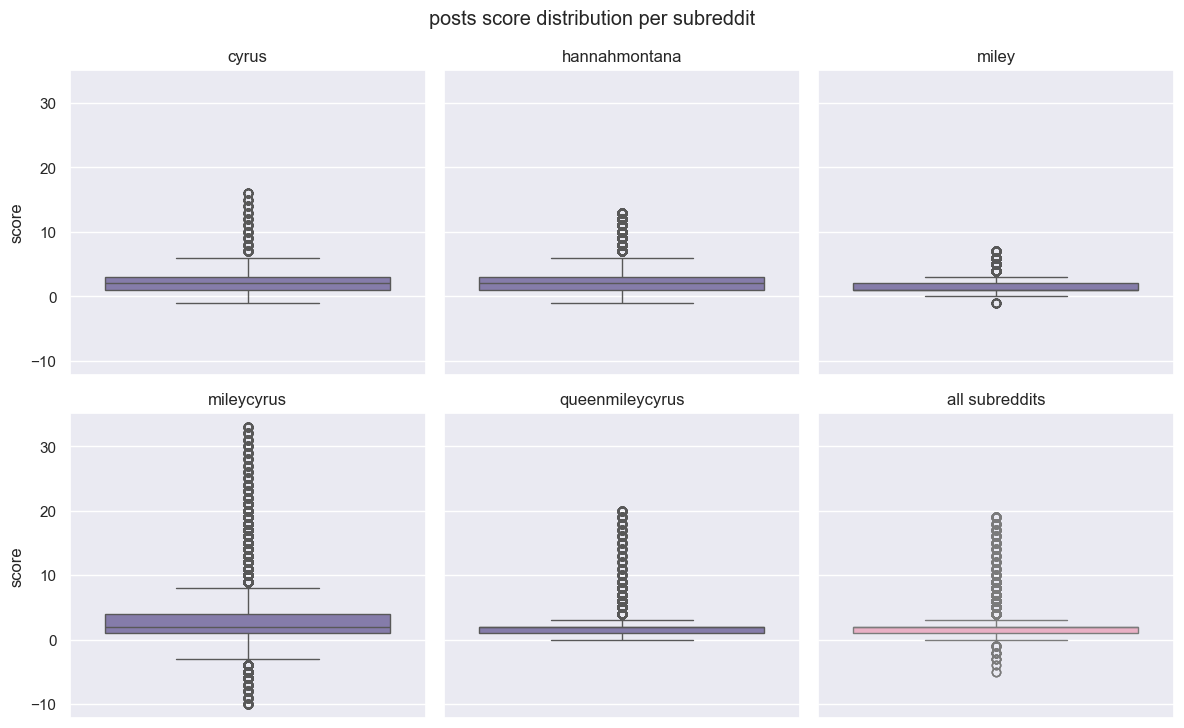

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(12, 12/1.618), sharey=True)
axes = axes.flatten()

for i, (sub, group) in enumerate(data.groupby("subreddit")):
    low = group["score"].quantile(0.01)
    high = group["score"].quantile(0.90)

    filtered = group.loc[(group["score"] >= low) & (group["score"] <= high)]

    sns.boxplot(
        y=filtered["score"],
        ax=axes[i],
        color="#8074B2"
    )

    axes[i].set_title(f"{sub}")
    axes[i].set_ylabel("score")
    axes[i].set_xlabel("")


low = data["score"].quantile(0.01)
high = data["score"].quantile(0.90)

filtered = group.loc[(data["score"] >= low) & (data["score"] <= high)]

sns.boxplot(
    y=filtered["score"],
    ax=axes[5],
    color="#F2A7C3"
)

axes[5].set_title(f"all subreddits")
axes[5].set_ylabel("score")
axes[5].set_xlabel("")

plt.suptitle("posts score distribution per subreddit")
plt.tight_layout()
plt.show()